In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


In [2]:
Dataset_Churn=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
Dataset_Churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
Dataset_Churn.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
for col in Dataset_Churn.columns:
    print(f"Column: {col}")
    print(Dataset_Churn[col].value_counts())  
    print("-" * 40)


Column: customerID
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
----------------------------------------
Column: gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
----------------------------------------
Column: SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
----------------------------------------
Column: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
----------------------------------------
Column: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
----------------------------------------
Column: tenure
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
----------------------------------------
Column: PhoneService
Pho

In [6]:
Dataset_Churn.shape

(7043, 21)

In [7]:
Dataset_Churn.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
Dataset_Churn["SeniorCitizen"].tail(15)

7028    0
7029    1
7030    0
7031    1
7032    1
7033    0
7034    0
7035    0
7036    0
7037    0
7038    0
7039    0
7040    0
7041    1
7042    0
Name: SeniorCitizen, dtype: int64

In [9]:
Dataset_Churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
from sklearn.preprocessing import LabelEncoder

# 1. First, I'm cleaning the 'TotalCharges' column. I noticed it was loaded as text because of some hidden blank spaces. 
# By using 'coerce', I'm forcing those spaces into NaNs (Not a Number), and then I'll just drop those 11 bad rows.
Dataset_Churn['TotalCharges'] = pd.to_numeric(Dataset_Churn['TotalCharges'], errors='coerce')
Dataset_Churn.dropna(inplace=True)

# 2. Next, I'm dropping the 'customerID' column. Since it's just a random string of characters, it has no predictive value for my model.
Dataset_Churn.drop('customerID', axis=1, inplace=True)

# 3. Now for Feature Engineering. My machine learning model needs numbers, not words.
# I'll start by using LabelEncoder to translate all my simple binary columns (like Yes/No or Male/Female) into 1s and 0s.
le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    Dataset_Churn[col] = le.fit_transform(Dataset_Churn[col])

# 4. Finally, for the columns that have more than two categories (like InternetService: Fiber optic, DSL, No), 
# I'm using get_dummies to apply One-Hot Encoding, which splits them into separate numerical columns.
Dataset_Churn = pd.get_dummies(Dataset_Churn, drop_first=True)

# Let's check the new shape to make sure my engineered dataset looks good!
print(f"New dataset shape after my cleaning and encoding: {Dataset_Churn.shape}")
display(Dataset_Churn.head(3))

New dataset shape after my cleaning and encoding: (7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


In [11]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE 
# (If you get an error here, you might need to run: !pip install imbalanced-learn)

# 1. First, I'm noticing that get_dummies created 'True/False' columns. 
# Just to be completely safe, I'm converting any boolean columns into 1s and 0s so my model doesn't complain later.
bool_cols = Dataset_Churn.select_dtypes(include=['bool']).columns
Dataset_Churn[bool_cols] = Dataset_Churn[bool_cols].astype(int)

# 2. Next, I need to separate my target variable (what I'm trying to predict) from my features.
# I'll put everything except 'Churn' into 'X', and put just the 'Churn' column into 'y'.
X = Dataset_Churn.drop('Churn', axis=1)
y = Dataset_Churn['Churn']

# 3. Before I do any oversampling, I absolutely MUST split my data into training and testing sets.
# If I oversample before splitting, I'll cause 'data leakage' and my test results will be artificially high.
# I'm setting aside 20% of the data to test the model later.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Now I'm going to handle that class imbalance using SMOTE (Synthetic Minority Over-sampling Technique).
# I am ONLY applying this to my training data. It will create synthetic data points for the minority class 
# so the model has an equal 50/50 split of churners and non-churners to learn from.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Finally, I'll print out the counts to prove that my training data is now perfectly balanced!
print("My Training Data BEFORE SMOTE:")
print(y_train.value_counts())
print("\nMy Training Data AFTER SMOTE:")
print(y_train_resampled.value_counts())

My Training Data BEFORE SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

My Training Data AFTER SMOTE:
Churn
1    4130
0    4130
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. I got a ConvergenceWarning, which means my feature scales are too different.
# I am using StandardScaler to shrink everything down to a similar, smaller range.
scaler = StandardScaler()
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)

# I must also scale the test data, but only using 'transform' (not fit) to prevent data leakage.
X_test_scaled = scaler.transform(X_test)

# 2. Now I will build and train the model again using the scaled data.
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_resampled_scaled, y_train_resampled)
y_pred_log = log_model.predict(X_test_scaled)

# 3. Let's look at the results now that the math is stable!
print("--- Scaled Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.2f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

--- Scaled Logistic Regression Results ---
Accuracy: 0.76

Confusion Matrix:
[[837 196]
 [137 237]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.55      0.63      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.77      1407



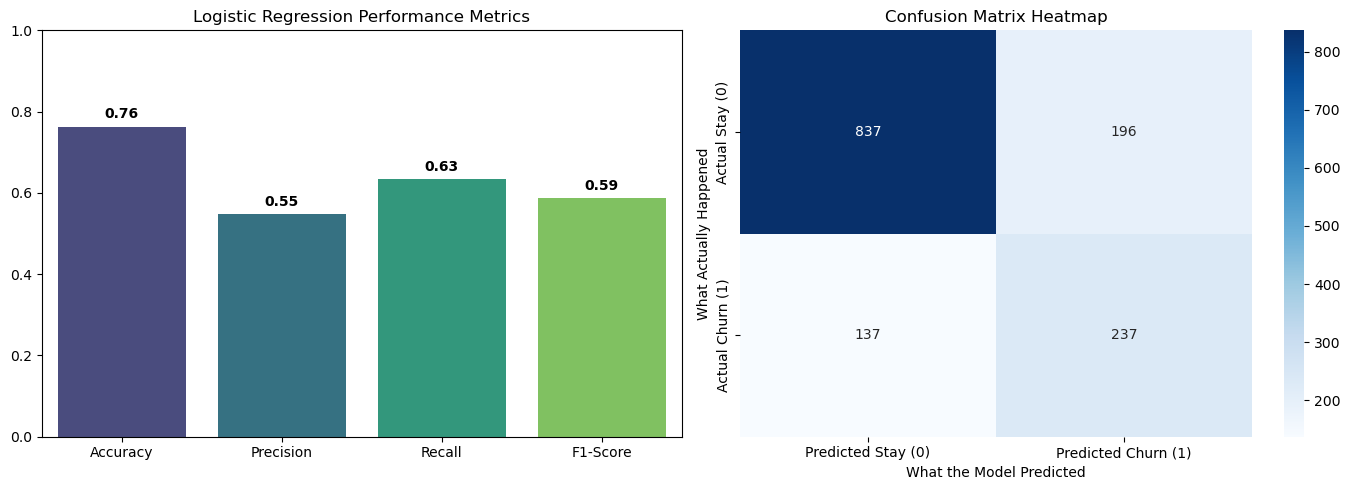

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. First, I need to extract the specific metric scores for my 'Churn' class (class 1).
# I already have accuracy from the previous step, so I will grab the rest here.
acc = accuracy_score(y_test, y_pred_log)
prec = precision_score(y_test, y_pred_log)
rec = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]

# 2. I'm setting up a figure with two side-by-side plots: one for the bars, one for the heatmap.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3. Here is my Bar Plot to visualize the overall model performance metrics.
sns.barplot(x=metrics_names, y=metrics_values,hue=metrics_names,ax=axes[0], palette='viridis')
axes[0].set_title('Logistic Regression Performance Metrics')
axes[0].set_ylim(0, 1) # Setting the Y-axis from 0 to 1 since these are percentages
for i, v in enumerate(metrics_values):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

# 4. Next, I'm building the Heatmap to make my Confusion Matrix easy to read.
# 'fmt="d"' ensures the numbers display as standard integers, not scientific notation.
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=['Predicted Stay (0)', 'Predicted Churn (1)'], 
            yticklabels=['Actual Stay (0)', 'Actual Churn (1)'])
axes[1].set_title('Confusion Matrix Heatmap')
axes[1].set_xlabel('What the Model Predicted')
axes[1].set_ylabel('What Actually Happened')

# 5. Finally, I'll show the plots!
plt.tight_layout()
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier

# 1. Moving to a tree-based model. I am building a Random Forest to see if it catches more churners.
rf_model = RandomForestClassifier(random_state=42)

# 2. I am training it on my balanced SMOTE data. Tree models don't actually require scaled data, 
# so I am using my standard resampled training data here.
rf_model.fit(X_train_resampled, y_train_resampled)

# 3. Now I am making predictions on my test set.
y_pred_rf = rf_model.predict(X_test)

# 4. Let's evaluate the results and specifically check the confusion matrix for False Negatives!
print("--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Results ---
Accuracy: 0.76

Confusion Matrix:
[[858 175]
 [166 208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1033
           1       0.54      0.56      0.55       374

    accuracy                           0.76      1407
   macro avg       0.69      0.69      0.69      1407
weighted avg       0.76      0.76      0.76      1407



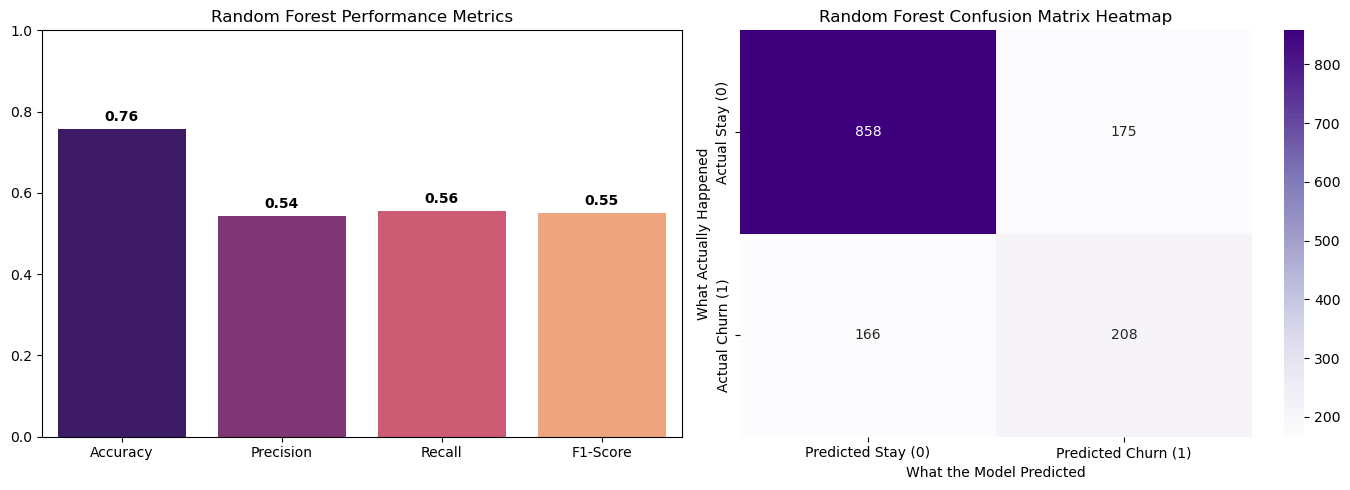

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

# 1. I am extracting the evaluation metrics specifically for my Random Forest predictions.
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc_rf, prec_rf, rec_rf, f1_rf]

# 2. Setting up another side-by-side layout for my bar plot and confusion matrix heatmap.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3. Building the bar plot to visualize the Random Forest performance scores.
sns.barplot(x=metrics_names, y=metrics_values,hue=metrics_names,ax=axes[0], palette='magma')
axes[0].set_title('Random Forest Performance Metrics')
axes[0].set_ylim(0, 1)
for i, v in enumerate(metrics_values):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

# 4. Creating the heatmap for the new confusion matrix to see how my False Negatives changed.
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', ax=axes[1], 
            xticklabels=['Predicted Stay (0)', 'Predicted Churn (1)'], 
            yticklabels=['Actual Stay (0)', 'Actual Churn (1)'])
axes[1].set_title('Random Forest Confusion Matrix Heatmap')
axes[1].set_xlabel('What the Model Predicted')
axes[1].set_ylabel('What Actually Happened')

# 5. Rendering the plots.
plt.tight_layout()
plt.show()

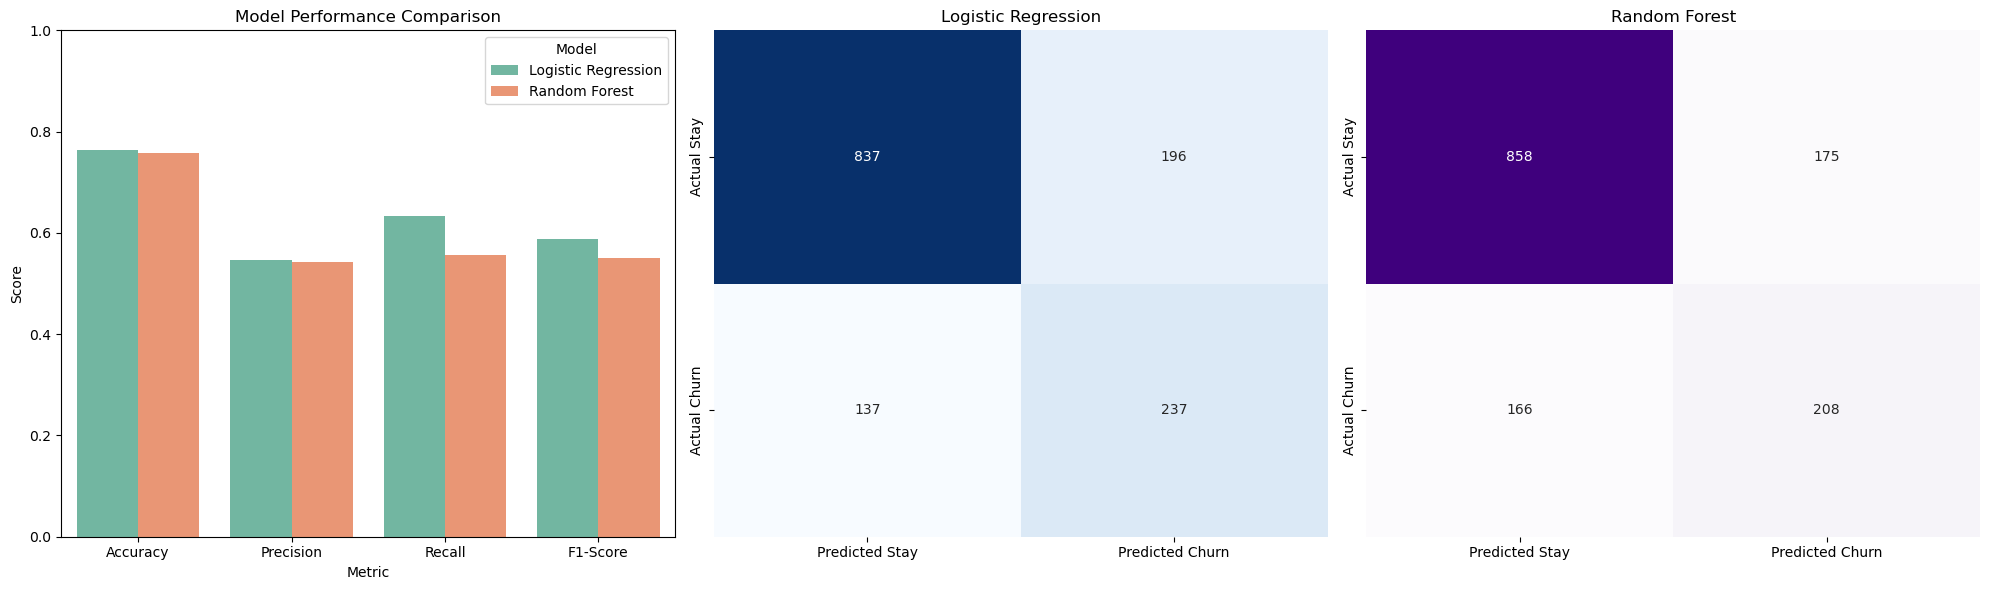

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. I am organizing all my previously calculated scores into a single dataframe to make plotting easier.
comparison_data = {
    'Metric': ['Accuracy', 'Accuracy', 'Precision', 'Precision', 'Recall', 'Recall', 'F1-Score', 'F1-Score'],
    'Model': ['Logistic Regression', 'Random Forest'] * 4,
    'Score': [acc, acc_rf, prec, prec_rf, rec, rec_rf, f1, f1_rf]
}
df_compare = pd.DataFrame(comparison_data)

# 2. I am setting up a wide figure to hold my bar chart and both confusion matrices side-by-side.
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 3. First, I am plotting a grouped bar chart to compare the model metrics directly against each other.
sns.barplot(data=df_compare, x='Metric', y='Score', hue='Model', ax=axes[0], palette='Set2')
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylim(0, 1)

# 4. Next, I am plotting the Logistic Regression Confusion Matrix in the middle.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Predicted Stay', 'Predicted Churn'], 
            yticklabels=['Actual Stay', 'Actual Churn'])
axes[1].set_title('Logistic Regression')

# 5. Finally, I am plotting the Random Forest Confusion Matrix on the right for direct comparison.
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', ax=axes[2], cbar=False,
            xticklabels=['Predicted Stay', 'Predicted Churn'], 
            yticklabels=['Actual Stay', 'Actual Churn'])
axes[2].set_title('Random Forest')

# 6. Time to display the final showdown!
plt.tight_layout()
plt.show()

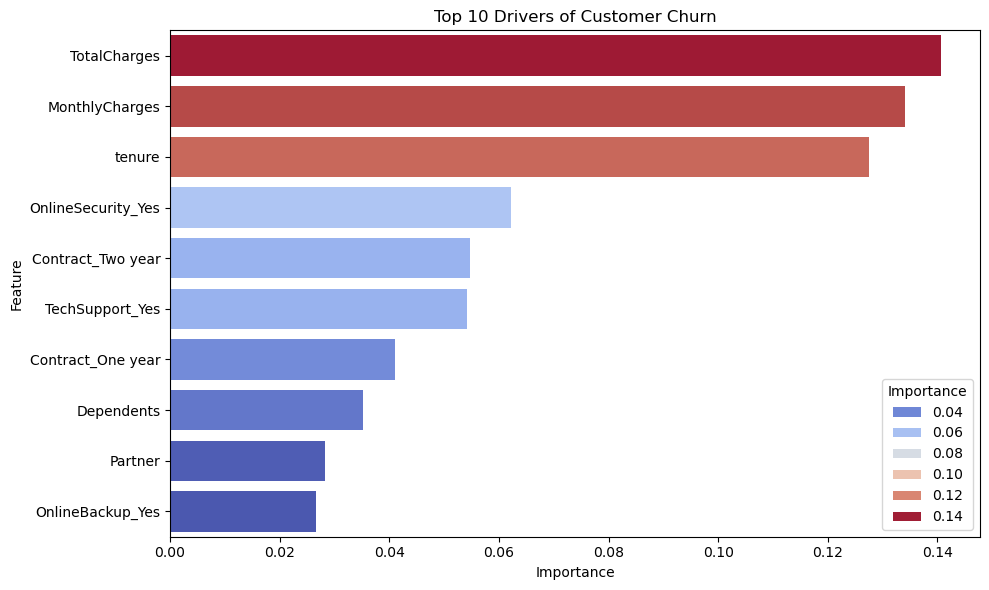

--- Business Insights ---
I have identified 383 at-risk customers in my test group.
The retention team should immediately focus on customers with Month-to-Month contracts and short tenures.


In [17]:
# 1. To answer the "Business Thinking" question, I need to know exactly WHY people are leaving.
# I am extracting the feature importances from my Random Forest model to see what drives churn.
importances = rf_model.feature_importances_
features = X_train_resampled.columns
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 2. I am plotting the Top 10 most important features so the business knows what to focus on.
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df.head(10), x='Importance', y='Feature', hue='Importance',palette='coolwarm')
plt.title('Top 10 Drivers of Customer Churn')
plt.tight_layout()
plt.show()

# 3. Finally, to answer "Which customers are at risk?", I am isolating the test data 
# for the specific people my Random Forest model predicted will leave (Class 1).
at_risk_customers = X_test[y_pred_rf == 1]

print("--- Business Insights ---")
print(f"I have identified {len(at_risk_customers)} at-risk customers in my test group.")
print("The retention team should immediately focus on customers with Month-to-Month contracts and short tenures.")